# M4-B1 — Benchmark Mistral Assurances

> Concevoir une IA simple : benchmark 3+ familles de modèles + grille
> de décision. Référence baseline : `mistral-tarif-v1` (R² 0.39).

Auteur·rice : `Alexandre` — Date : `18/08/2026`

**Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [39]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append('../src')

RANDOM_STATE = 42
DATA_PATH = Path('../data/bike_sharing.csv')
sns.set_theme(style='whitegrid')

## 1. Reprise baseline mistral-tarif-v1 (~30 min)

Charge le modèle baseline depuis le repo `mistral-tarif-v1`, note ses
métriques rapportées (R² 0.39, MAE 105, RMSE 139), identifie les angles
morts du code 2024 (cf. mini-cours 04 méthodologie benchmark).

In [40]:
# Étape 1 — charger le baseline mistral-tarif-v1.
# Prérequis : cloner le repo baseline EN VOISIN de ton repo M4-B1
# (dans le dossier PARENT, pour que le chemin ../../ ci-dessous fonctionne) :
#   git clone https://github.com/Formation-SIMPLON-IA/mistral-tarif-v1.git
import joblib

# suppose le baseline cloné en voisin de ton repo M4-B1
model_v1 = joblib.load("../../mistral-tarif-v1/models/mistral_tarif_v1.joblib")
model_v1


LinearRegression()

## 2. EDA orientée saisonnalité (~1h30)

Au moins **4 visualisations Seaborn** : boxplot par saison, courbe par
heure-moyenne, scatter température vs cnt, corrélations.

> *« Quelle saisonnalité je vois ? Comment elle explique la
> sous-performance de la baseline ? »*

In [41]:
df = pd.read_csv(DATA_PATH)
df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      17379 non-null  int64  
 1   date                    17379 non-null  object 
 2   season                  17379 non-null  object 
 3   year                    17379 non-null  int64  
 4   month                   17379 non-null  int64  
 5   hour                    17379 non-null  int64  
 6   is_holiday              17379 non-null  int64  
 7   weekday                 17379 non-null  int64  
 8   is_working_day          17379 non-null  int64  
 9   weather                 17379 non-null  int64  
 10  temperature_norm        17379 non-null  float64
 11  temperature_feels_norm  17379 non-null  float64
 12  humidity_norm           17379 non-null  float64
 13  windspeed_norm          17379 non-null  float64
 14  casual_riders           17379 non-null

,id,date,season,year,month,hour,is_holiday,weekday,is_working_day,weather,temperature_norm,temperature_feels_norm,humidity_norm,windspeed_norm,casual_riders,registered_riders,total_rentals
0,1,2011-01-01,winter,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,winter,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,winter,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


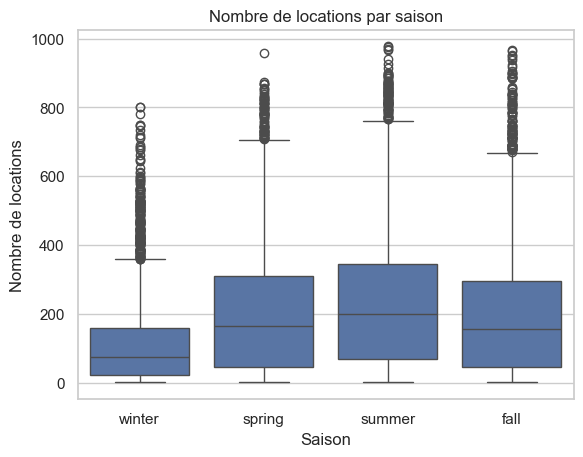

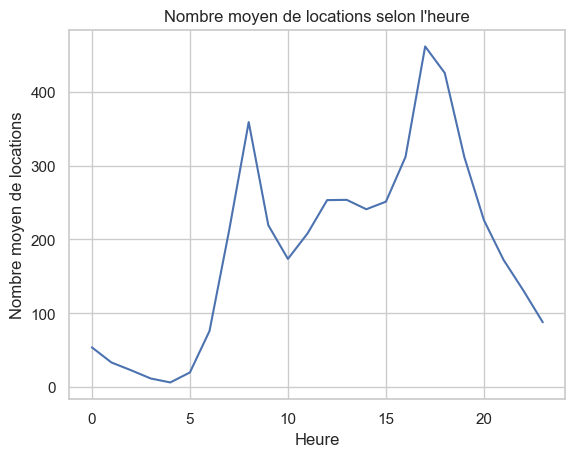

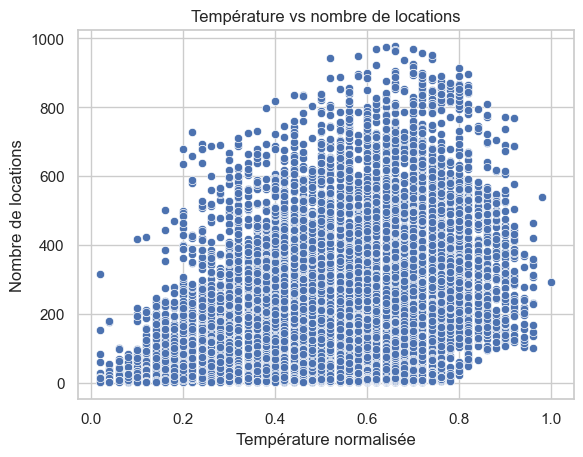

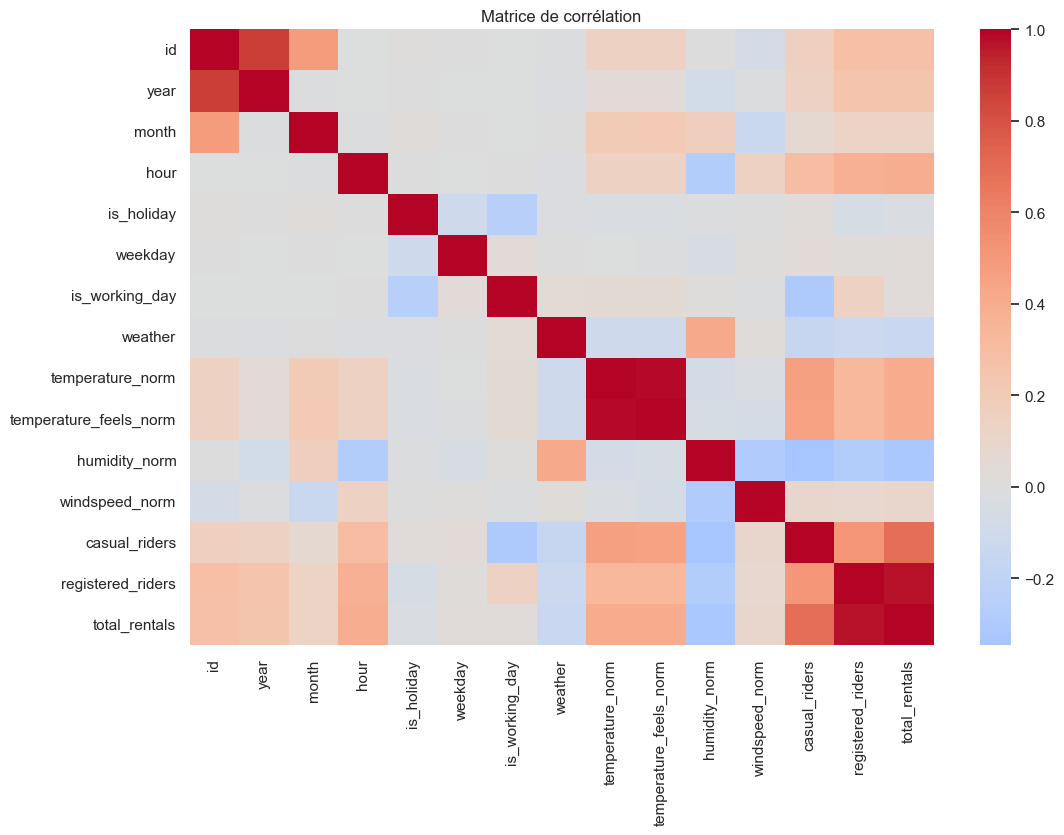

In [42]:
# TODO — 4 visualisations EDA
# (boxplot par saison, courbe par heure-moyenne, scatter temp vs cnt, heatmap corrélations)
# Boxplot par saison
sns.boxplot(data=df, x="season", y="total_rentals")
plt.title("Nombre de locations par saison")
plt.xlabel("Saison")
plt.ylabel("Nombre de locations")
plt.show()

# Courbe du nombre moyen de locations par heure
hourly_mean = df.groupby("hour")["total_rentals"].mean()

hourly_mean.plot()
plt.title("Nombre moyen de locations selon l'heure")
plt.xlabel("Heure")
plt.ylabel("Nombre moyen de locations")
plt.show()

# Scatter température vs nombre de locations
sns.scatterplot(data=df, x="temperature_norm", y="total_rentals")
plt.title("Température vs nombre de locations")
plt.xlabel("Température normalisée")
plt.ylabel("Nombre de locations")
plt.show()

# Heatmap des corrélations
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()

### Conclusion de l'EDA

En 5 lignes maximum :

- Les variables les plus importantes semblent être l'heure, la saison, la température, la température ressentie et l'humidité.
- La baseline linéaire risque d'etre limitée car on a des variations non linéaires (par exemple l'heure et les conditions météo).
- Elle représente également mal les interactions entre les variables (par exemple l'effet combiné de la température et de la saison sur le nombre de locations).
- Je m'attend a voir gagner un modèle plus complexe (arbre ou boosting) sur la baseline linéaire.

## 3. Split argumenté + validation croisée (~30 min)

Choisir **`TimeSeriesSplit`** ou **`KFold` stratifié** — justifier.

Mini-cours 02 (split temporel vs stratifié) à consulter.

> 🎓 **Réflexe anti-fuite (la leçon de M2-B1, enfin mise en œuvre).** En M2-B1 tu
> as construit un `Pipeline` sans modèle ni split : la fuite ne pouvait pas se
> produire. Ici tu as **un split ET un modèle** → la règle s'applique : un
> préprocesseur **qui apprend des paramètres** (`StandardScaler`, `SimpleImputer`)
> ne se `fit` **jamais** sur l'ensemble des données. On l'enferme dans le
> `Pipeline` du modèle, et c'est **ce Pipeline** qu'on passe à la validation
> croisée — scikit-learn re-`fit` alors le scaler sur les seuls folds
> d'entraînement. Sinon : fuite → R² **optimiste mensonger**. On le démontre
> juste en dessous.


On utilise ici un TimeSeriesSplit car les données sont temporelles (location de vélos au fil du temps). Un KFold stratifié ne respecterait pas l'ordre chronologique des données, ce qui pourrait introduire des fuites d'information entre les ensembles d'entraînement et de test.

Le TimeSeriesSplit permet de créer des splits qui respectent la séquence temporelle, garantissant que les modèles sont évalués sur des données futures par rapport à celles sur lesquelles ils ont été entraînés.

In [43]:
# TODO — Choisir et importer le splitter adapté (TimeSeriesSplit ou KFold)
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

from preprocess import (
    load_dataset,
    add_cyclic_features,
    build_preprocessor,
)

X, y = load_dataset(Path("../data/bike_sharing.csv"))
X = add_cyclic_features(X)

model = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("ridge", Ridge(alpha=1.0)),
])

splitter = TimeSeriesSplit(n_splits=5)

scores = cross_val_score(
    model,
    X,
    y,
    cv=splitter,
    scoring="neg_mean_absolute_error"
)

print(f"MAE : {-scores.mean():.2f} ± {scores.std():.2f}")

MAE : 115.01 ± 24.17


### 🔬 Fuites de données — démonstration (à faire une fois)

La cellule compare **trois** situations en validation croisée (Ridge) :
la **fuite de cible** (`casual_riders`/`registered_riders` dans X — ils
somment la cible), la **fuite de prétraitement** (`StandardScaler` fitté sur
**tout** X avant la CV) et la version **propre** (scaler dans le `Pipeline`).

> **À rédiger après exécution** (2-3 phrases, → journal de bord) : la fuite de
> cible crève l'écran (R² ≈ 1.0) ; la fuite de prétraitement est **quasi
> invisible ici** (~±0.0005 sur 17k lignes, parfois même légèrement négative —
> c'est du bruit). Explique *dans quel cas* elle exploserait (peu de données,
> imputation moyenne/médiane, encodage supervisé) — et donc pourquoi on
> encapsule le prétraitement **par défaut** : cette fuite-là ne prévient pas.


In [44]:
# 🔬 Démonstration fuites vs propre (Ridge) — à exécuter une fois le
# preprocessing complété (FEATURES rempli dans preprocess.py).
# Cellule pré-écrite : tu n'as pas à la coder, juste à la faire tourner.
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from preprocess import load_dataset, add_cyclic_features, build_preprocessor

# Chargement propre
X_demo, y_demo = load_dataset(DATA_PATH)
X_demo = add_cyclic_features(X_demo)

df_full = pd.read_csv(DATA_PATH)
splitter_demo = TimeSeriesSplit(n_splits=5)

def clean_pipe():
    return Pipeline([
        ("preprocessor", build_preprocessor()),
        ("ridge", Ridge(alpha=1.0))
    ])

# 0) FUITE DE CIBLE
X_cible = X_demo.assign(
    casual_riders=df_full["casual_riders"],
    registered_riders=df_full["registered_riders"]
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_demo = [
    "season",
    "weather",
    "weekday",
]

numeric_demo = [
    col for col in X_cible.columns
    if col not in categorical_demo
]

leaky_target_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_demo),
    ("num", StandardScaler(), numeric_demo),
])

target_leak_pipe = Pipeline([
    ("preprocessor", leaky_target_preprocessor),
    ("ridge", Ridge(alpha=1.0))
])

r2_cible = cross_val_score(
    target_leak_pipe,
    X_cible,
    y_demo,
    cv=splitter_demo,
    scoring="r2"
).mean()


# 1) FUITE DE PRÉTRAITEMENT
# Ici on fit volontairement le preprocessing sur TOUT X avant la CV
preprocessor_leak = build_preprocessor()
X_leak = preprocessor_leak.fit_transform(X_demo)

r2_leak = cross_val_score(
    Ridge(alpha=1.0),
    X_leak,
    y_demo,
    cv=splitter_demo,
    scoring="r2"
).mean()


# 2) VERSION PROPRE
r2_clean = cross_val_score(
    clean_pipe(),
    X_demo,
    y_demo,
    cv=splitter_demo,
    scoring="r2"
).mean()


display(pd.DataFrame(
    {
        "R² moyen (CV)": [
            round(r2_cible, 4),
            round(r2_leak, 4),
            round(r2_clean, 4),
        ],
        "écart vs propre": [
            format(r2_cible - r2_clean, "+.4f"),
            format(r2_leak - r2_clean, "+.5f"),
            "—",
        ],
    },
    index=[
        "fuite de CIBLE (riders dans X)",
        "fuite de PRÉTRAITEMENT",
        "propre (préprocessing dans le pipeline)",
    ],
))


,R² moyen (CV),écart vs propre
fuite de CIBLE (riders dans X),1.0000,+0.7358
fuite de PRÉTRAITEMENT,0.2641,-0.00011
propre (préprocessing dans le pipeline),0.2642,—


## 4. Benchmark — 3 familles minimum (~2h)

**Famille A** — Linéaire (Ridge ou variante)  
**Famille B** — Arbre / RandomForest  
**Famille C** — Gradient Boosting (HistGradientBoostingRegressor)

Pour chaque modèle :
- Mêmes folds, mêmes métriques
- MAE, RMSE, R²
- Temps train, latence inférence
- Persistance `.joblib` dans `models/`

> ⚠️ **Règle d'or** : réutilise **exactement le même splitter** que la section 3 (Split). Un splitter différent d'un modèle à l'autre = comparaison invalide.


In [45]:
# TODO — Définir les 3 familles de modèles (linéaire, forêt, boosting) et lancer run_benchmark().
# Anti-fuite : pour le modèle linéaire, le StandardScaler vit DANS la factory
# (make_pipeline) -> run_benchmark le re-fit sur chaque fold d'entraînement.
# Les arbres/boosting n'ont pas besoin de scaling.
#

from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from preprocess import build_preprocessor
from train_models import run_benchmark


models = {
    "Ridge": lambda: Pipeline([
        ("preprocessor", build_preprocessor()),
        ("model", Ridge(alpha=1.0)),
    ]),

    "RandomForest": lambda: Pipeline([
        ("preprocessor", build_preprocessor()),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
        )),
    ]),

    "HistGradientBoosting": lambda: Pipeline([
        ("preprocessor", build_preprocessor()),
        ("model", HistGradientBoostingRegressor(
            random_state=42,
        )),
    ]),
}


benchmark_results = run_benchmark(
    models,
    X,
    y,
    splitter,
)

display(benchmark_results.sort_values("mae"))


,mae,rmse,r2,fit_time_sec,predict_time_ms_per_1k
model,,,,,
HistGradientBoosting,49.8350,74.0302,0.8049,0.1758,3.5873
RandomForest,52.8587,79.3751,0.7800,0.3566,31.6474
Ridge,115.0057,153.5447,0.2642,0.0076,2.4170


## 5. Tableau comparatif (~30 min, mercredi)

Remplis `benchmark_table.md` avec les chiffres + interprétation pour
Inès Tabet (lisible actuaire, pas data scientist).

## 6. Verdict + decision card (~30 min, mercredi)

- `verdict.md` : 5 lignes max, recommandation chiffrée
- `decision_card.md` : ta version perso de la grille de décision C4
  (à confronter à la collective)

## 7. Restitution + grille collective (mercredi 11h30-12h45)

**Geste pédagogique central** — co-construction de la grille de
décision C4 sur Excalidraw partagé.

Archivée ensuite dans `ressources-publiques/grille_decision_C4.md`.